# Quantum response reconstruction

A hidden Qiskit circuit produces a periodic response of a linear feature. We observe inputs and expectation values, recover the unknown waveform and eight weights, and export the result as a differentiable classical model and a response-equivalent circuit.

The waveform comes from a known family of 62 waveforms. This example uses 40 fractional bits and ideal statevector simulation; it does not model noisy hardware.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from phaselattice import reconstruct
from phaselattice.io import read_json
from phaselattice.observations import load_public

root = Path.cwd()
if not (root / "evidence").exists():
    root = root.parent
case = root / "evidence/cases/quantum_d08_s00"
public = case / "observations.json.gz"
metadata, splits = load_public(public)
print(
    f"{splits['train'].inputs.shape[1]} features; "
    f"{len(splits['train'].outputs)} training observations; "
    f"{len(splits['validation'].outputs)} validation observations"
)

8 features; 1024 training observations; 128 validation observations


## Infer from observations

Only the public file is passed to the decoder. Its metadata contain the family degree, coefficient denominator, norm bound and precision. They contain no teacher weights, waveform index, seed or test labels.

In [2]:
result = reconstruct(public)
assert result.recovered
check = result.verify(public)
assert check["valid"]
model = result.model
print("Waveform coefficients:", model.coefficients, "/", model.denominator)
print("Recovered weights:", np.round(model.theta, 6))
print("Verified phase assignments:", check["rows"])
print("Maximum selected-phase residual:", f"{check['max_phase_residual']:.2e}")

Waveform coefficients: (-1, 2, 1) / 4
Recovered weights: [ 1.105631 -0.304642  0.094371 -0.06882   0.00276   0.829939  0.208507
  0.434569]
Verified phase assignments: 16
Maximum selected-phase residual: 3.37e-13


The left plot shows observed responses against the first input coordinate. The right plot shows the same responses against the inferred phase, together with the reconstructed waveform. Reference parameters have not been opened at this point.

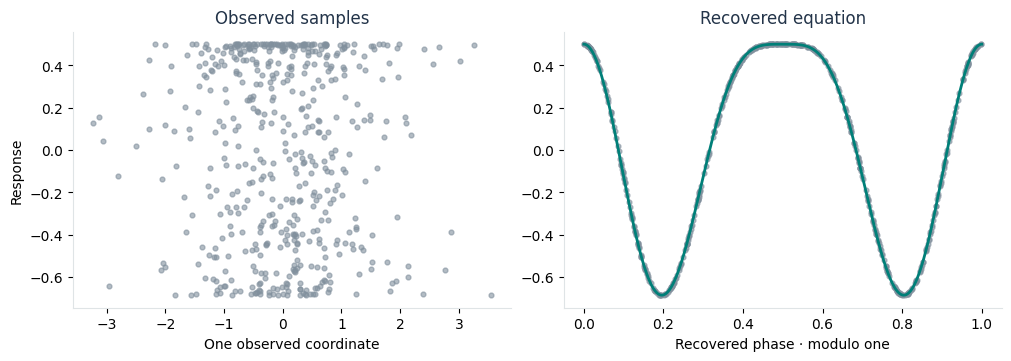

In [3]:
plt.rcParams.update(
    {
        "font.family": "DejaVu Sans",
        "font.size": 10,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.edgecolor": "#DFE4E6",
        "text.color": "#233449",
    }
)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), layout="constrained")
x, y = splits["train"].inputs[:512], splits["train"].outputs[:512]
axes[0].scatter(x[:, 0], y, s=12, color="#81909D", alpha=0.6)
axes[0].set(xlabel="One observed coordinate", ylabel="Response", title="Observed samples")
axes[1].scatter((x @ model.theta) % 1, y, s=12, color="#81909D", alpha=0.6)
t = np.linspace(0, 1, 1000)
wave = sum(
    k * np.cos(2 * np.pi * j * t) / model.denominator for j, k in enumerate(model.coefficients, 1)
)
axes[1].plot(t, wave, color="#007F78", lw=2)
axes[1].set(xlabel="Recovered phase · modulo one", title="Recovered equation")
plt.show()

## Evaluate after learning

We now open the separate test set and reference parameters. Reconstruction requires the correct waveform, weight error below `1e-4` up to sign, and test MSE/variance below `1e-6`. The optimizer comparison is read from the frozen benchmark; it is not fitted inside this notebook.

In [4]:
from phaselattice.evaluation import score

outcome = score(case, result.record)
optimizer = read_json(root / "evidence/run/quantum_d08_s00/optimizer-portfolio.json")
optimizer_outcome = score(case, optimizer)
print(
    f"PhaseLattice: recovered={outcome['recovered']}, "
    f"test MSE/variance={outcome['loss_over_variance']:.2e}"
)
print(
    f"Optimizer portfolio: recovered={optimizer_outcome['recovered']}, "
    f"test MSE/variance={optimizer_outcome['loss_over_variance']:.2e}"
)
assert outcome["recovered"]

PhaseLattice: recovered=True, test MSE/variance=5.15e-23
Optimizer portfolio: recovered=False, test MSE/variance=1.00e+00


## Differentiate the recovered model

The closed-form model gives input gradients and Hessian-vector products. PyTorch provides an independent implementation of those derivatives. We evaluate shifted inputs that were not used for reconstruction.

In [5]:
import torch

rng = np.random.default_rng(710)
inputs = 2 + rng.normal(size=(16, len(model.weights)))
vectors = rng.normal(size=inputs.shape)
tensor = torch.tensor(inputs, dtype=torch.float64, requires_grad=True)
y = model.as_torch()(tensor)
(gradient,) = torch.autograd.grad(y.sum(), tensor, create_graph=True)
(hvp,) = torch.autograd.grad((gradient * torch.tensor(vectors)).sum(), tensor)
np.testing.assert_allclose(model.gradient(inputs), gradient.detach(), atol=1e-12)
np.testing.assert_allclose(model.hessian_vector_product(inputs, vectors), hvp.detach(), atol=1e-11)
print("Analytic gradients and Hessian-vector products agree with PyTorch autograd.")

Analytic gradients and Hessian-vector products agree with PyTorch autograd.


## Rebuild the measured quantum response

The inferred harmonic coefficients become selector probabilities and controlled rotations. This produces a circuit with the same response, rather than identifying a unique original gate sequence. Feature parameters are bound in the returned order.

In [6]:
from qiskit.primitives import StatevectorEstimator

circuit, observable, features = model.as_qiskit()
publications = [
    (circuit.assign_parameters(dict(zip(features, row))), observable) for row in inputs[:8]
]
quantum = np.array(
    [float(item.data.evs) for item in StatevectorEstimator().run(publications).result()]
)
np.testing.assert_allclose(quantum, model.predict(inputs[:8]), atol=2e-14, rtol=0)
print(f"{circuit.num_qubits} qubits; {len(features)} feature parameters")
print(
    "Circuit / equation maximum difference:",
    f"{np.max(np.abs(quantum - model.predict(inputs[:8]))):.2e}",
)

3 qubits; 8 feature parameters
Circuit / equation maximum difference: 1.07e-14


In [7]:
from phaselattice.evaluation import quantum_roundtrip

reference = read_json(case / "reference.json")
roundtrip = quantum_roundtrip(model, reference, inputs[:8])
print(
    "Original / reconstructed circuit maximum difference:",
    f"{roundtrip['max_circuit_difference']:.2e}",
)
print(
    "Gradient error against original circuit finite differences:",
    f"{roundtrip['gradient_relative_rms_error']:.2e}",
)
assert roundtrip["max_circuit_difference"] < 1e-8
assert roundtrip["gradient_relative_rms_error"] < 1e-6

Original / reconstructed circuit maximum difference: 1.20e-11
Gradient error against original circuit finite differences: 2.43e-11


## Export

The standalone file requires NumPy. Its optional PyTorch and Qiskit interfaces import those packages only when used. The 44-model benchmark, precision sweep and shot-noise controls are reported in [the results](../docs/results.md).

In [8]:
destination = root / "runs/notebook"
result.save(destination / "reconstruction.json")
model.export(destination / "model.py")
print("Saved runs/notebook/reconstruction.json and runs/notebook/model.py")

Saved runs/notebook/reconstruction.json and runs/notebook/model.py
